In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import sklearn
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from mhealth_activity.recording import Recording
from mhealth_activity.types import Activity
from mhealth_activity import WatchLocation
from mhealth_activity import Trace
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import median_filter, uniform_filter1d
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Step Count #

## Windowed & peak-based ##

Estimate steps from accelerometer magnitude using local peak detection.

Method (brief):

- Compute a_mag, remove mean, bandpass (≈0.7–3 Hz)
- Split into short windows (~10 s)
- Detect peaks per window (distance + prominence)
- Keep windows with plausible cadence (≈1.3–2.8 Hz)
- Sum peaks → step count

In [ ]:


# DON'T TOUCH the hyperparameters, they are tuned and won't get better.
def estimate_steps_windowed(
    rec,
    window_s=10.0,
    low_hz=0.7,
    high_hz=3.0,
    peak_prominence=0.14,
    max_step_hz=3.0,
    min_peak_rate_hz=1.3,
    min_std_threshold=0.08,
    min_final_steps_to_keep=80,
):
    ax = rec.data["ax"].values.astype(float)
    ay = rec.data["ay"].values.astype(float)
    az = rec.data["az"].values.astype(float)
    fs = float(rec.data["ax"].samplerate)

    mag = np.sqrt(ax**2 + ay**2 + az**2)
    mag_centered = mag - np.mean(mag)

    nyq = fs / 2.0
    b, a = butter(3, [low_hz / nyq, high_hz / nyq], btype="band")
    filt = filtfilt(b, a, mag_centered)

    win_len = int(window_s * fs)
    min_distance = int(fs / max_step_hz)

    total_steps = 0
    kept_windows = []

    for start in range(0, len(filt), win_len):
        end = min(start + win_len, len(filt))
        segment = filt[start:end]

        if len(segment) < max(10, min_distance):
            continue

        # energy-based gating
        seg_std = float(np.std(segment))
        if seg_std < min_std_threshold:
            continue

        peaks, props = find_peaks(
            segment,
            distance=max(1, min_distance),
            prominence=peak_prominence,
        )

        duration = len(segment) / fs
        peak_rate_hz = len(peaks) / max(duration, 1e-9)

        if peak_rate_hz > min_peak_rate_hz:
            total_steps += len(peaks)
            kept_windows.append((start, end, len(peaks), peak_rate_hz, seg_std))

    # global cleanup for tiny false positives
    if total_steps < min_final_steps_to_keep:
        total_steps = 0

    return {
        "steps_hat": int(total_steps),
        "filtered_signal": filt,
        "fs": fs,
        "kept_windows": kept_windows,
    }

# Path Classification

In [ ]:
TRAIN_DIR = Path('data/train')
train_files = sorted(TRAIN_DIR.glob('*.pkl'))

def clean_altitude(values, timestamps, max_jump=5.0, smooth_window=5):
    mask = np.ones(len(values), dtype=bool)
    last_valid = values[0]
    for i in range(1, len(values)):
        if abs(values[i] - last_valid) > max_jump:
            mask[i] = False
        else:
            last_valid = values[i]
    return median_filter(values[mask], size=smooth_window), timestamps[mask]

def extract_sensor_features(values, timestamps, prefix, window_sec=50):
    slope, _ = np.polyfit(timestamps, values, 1)
    mid = len(values) // 2
    slope_first,  _ = np.polyfit(timestamps[:mid], values[:mid], 1)
    slope_second, _ = np.polyfit(timestamps[mid:], values[mid:], 1)
    win = max(3, len(values) // 10)
    local_slopes = [
        abs(np.polyfit(timestamps[i:i+win], values[i:i+win], 1)[0])
        for i in range(len(values) - win)
    ]
    min_local_slope = min(local_slopes)
    flattest_pos = np.argmin(local_slopes) / len(local_slopes)
    t0, t_end = timestamps[0], timestamps[-1]
    first_mask = timestamps <= t0 + window_sec
    last_mask  = timestamps >= t_end - window_sec
    first_max = values[first_mask].max() if first_mask.any() else values[0]
    last_min  = values[last_mask].min()  if last_mask.any()  else values[-1]
    return {
        f'{prefix}_start':           values[0],
        f'{prefix}_end':             values[-1],
        f'{prefix}_delta':           values[-1] - values[0],
        f'{prefix}_range':           values.max() - values.min(),
        f'{prefix}_mean':            values.mean(),
        f'{prefix}_slope':           slope,
        f'{prefix}_slope_first':     slope_first,
        f'{prefix}_slope_second':    slope_second,
        f'{prefix}_slope_diff':      slope_second - slope_first,
        f'{prefix}_min_local_slope': min_local_slope,
        f'{prefix}_flattest_pos':    flattest_pos,
        f'{prefix}_window_delta':    last_min - first_max,
    }

def extract_stop_features(rec, stop_std_threshold=0.04, min_stop_sec=3.0):
    ax = rec.data['ax'].values
    ay = rec.data['ay'].values
    az = rec.data['az'].values
    ts = rec.data['ax'].timestamps
    fs = rec.data['ax'].samplerate
    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    win = max(3, int(fs * 1.0))
    n = len(a_mag)
    rolling_std = np.array([a_mag[max(0, i-win//2): i+win//2+1].std() for i in range(n)])
    is_stopped = rolling_std < stop_std_threshold
    dt = np.diff(ts, prepend=ts[0])
    n_stops, total_stop_dur, longest_stop = 0, 0.0, 0.0
    in_stop, current_dur = False, 0.0
    for i, stopped in enumerate(is_stopped):
        if stopped:
            current_dur += dt[i]; in_stop = True
        else:
            if in_stop and current_dur >= min_stop_sec:
                n_stops += 1; total_stop_dur += current_dur
                longest_stop = max(longest_stop, current_dur)
            in_stop = False; current_dur = 0.0
    if in_stop and current_dur >= min_stop_sec:
        n_stops += 1; total_stop_dur += current_dur
        longest_stop = max(longest_stop, current_dur)
    return {'n_stops': n_stops, 'total_stop_duration': total_stop_dur, 'longest_stop': longest_stop}

def _circ_mean_std(angles_deg):
    rad = np.deg2rad(angles_deg)
    S, C = np.mean(np.sin(rad)), np.mean(np.cos(rad))
    R = np.sqrt(S**2 + C**2)
    mean_dir = np.rad2deg(np.arctan2(S, C)) % 360
    circ_std  = np.rad2deg(np.sqrt(max(0.0, -2 * np.log(R + 1e-10))))
    return mean_dir, circ_std

def _circ_diff(a, b):
    return (a - b + 180) % 360 - 180

def extract_orientation_features(rec, n_segs=8):
    seg_keys = [f'azimuth_s{i}' for i in range(n_segs)]
    diff_keys = [f'azimuth_s{i}_s{i-1}' for i in range(1, n_segs)]
    NAN_KEYS = ['azimuth_mean', 'azimuth_std',
                'azimuth_first_mean', 'azimuth_mid_mean', 'azimuth_last_mean',
                'azimuth_mid_std', 'azimuth_n_turns'] + seg_keys + diff_keys

    azimuth, fs = None, 1.0

    if 'phone_orientationx' in rec.data:
        trace = rec.data['phone_orientationx']
        azimuth = trace.values
        fs = trace.samplerate
        src = 1
    elif 'mx' in rec.data and 'my' in rec.data:
        mx = rec.data['mx'].values
        my = rec.data['my'].values
        azimuth = np.rad2deg(np.arctan2(my, mx)) % 360
        fs = rec.data['mx'].samplerate
        src = 2
    else:
        return {'has_azimuth': 0, **{k: np.nan for k in NAN_KEYS}}

    win = max(3, int(fs * 5))
    s_smooth = uniform_filter1d(np.sin(np.deg2rad(azimuth)), size=win)
    c_smooth = uniform_filter1d(np.cos(np.deg2rad(azimuth)), size=win)
    az_smooth = np.rad2deg(np.arctan2(s_smooth, c_smooth)) % 360

    n = len(az_smooth)
    t1, t2 = n // 3, 2 * n // 3

    mean_all, std_all = _circ_mean_std(az_smooth)
    mean_fst, _       = _circ_mean_std(az_smooth[:t1])
    mean_mid, std_mid = _circ_mean_std(az_smooth[t1:t2])
    mean_lst, _       = _circ_mean_std(az_smooth[t2:])

    edges = [int(n * i / n_segs) for i in range(n_segs + 1)]
    seg_means = [_circ_mean_std(az_smooth[edges[i]:edges[i+1]])[0] for i in range(n_segs)]
    seg_feats = {f'azimuth_s{i}': seg_means[i] for i in range(n_segs)}
    diff_feats = {f'azimuth_s{i}_s{i-1}': _circ_diff(seg_means[i], seg_means[i-1])
                  for i in range(1, n_segs)}

    d_az = np.diff(az_smooth)
    d_az = (d_az + 180) % 360 - 180
    in_turn, n_turns = False, 0
    for da in d_az:
        if abs(da) > 10 and not in_turn:
            in_turn = True; n_turns += 1
        elif abs(da) <= 10:
            in_turn = False

    return {
        'has_azimuth':        src,
        'azimuth_mean':       mean_all,
        'azimuth_std':        std_all,
        'azimuth_first_mean': mean_fst,
        'azimuth_mid_mean':   mean_mid,
        'azimuth_last_mean':  mean_lst,
        'azimuth_mid_std':    std_mid,
        'azimuth_n_turns':    n_turns,
        **seg_feats,
        **diff_feats,
    }

def extract_features(rec):
    features = {}
    features['duration'] = rec.data['ax'].total_time

    pressure_keys = ['pressure_start','pressure_end','pressure_delta','pressure_range',
                     'pressure_mean','pressure_slope','pressure_slope_first',
                     'pressure_slope_second','pressure_slope_diff',
                     'pressure_min_local_slope','pressure_flattest_pos','pressure_window_delta']
    altitude_keys = [k.replace('pressure', 'altitude') for k in pressure_keys]

    if 'phone_pressure' in rec.data:
        p = rec.data['phone_pressure']
        features.update(extract_sensor_features(p.values, p.timestamps, 'pressure'))
        features['has_pressure'] = 1
    else:
        for k in pressure_keys: features[k] = np.nan
        features['has_pressure'] = 0

    if 'altitude' in rec.data:
        a = rec.data['altitude']
        cleaned, ts_clean = clean_altitude(a.values, a.timestamps)
        if len(cleaned) > 1:
            features.update(extract_sensor_features(cleaned, ts_clean, 'altitude'))
        features['has_altitude'] = 1
    else:
        for k in altitude_keys: features[k] = np.nan
        features['has_altitude'] = 0

    features.update(extract_stop_features(rec))
    features.update(extract_orientation_features(rec))

    return features

# Load & cache features

In [ ]:
FEATURES_CACHE = 'data/path_features.csv'

if os.path.exists(FEATURES_CACHE):
    X = pd.read_csv(FEATURES_CACHE, index_col=0)
    labels = X.pop('label').values
    print(f"Loaded from cache ({len(X)} recordings)")
else:
    all_features, all_labels = [], []
    for f in train_files:
        r = Recording(str(f))
        all_labels.append(r.labels['path_idx'])
        all_features.append(extract_features(r))
    X = pd.DataFrame(all_features)
    labels = np.array(all_labels)
    X['label'] = labels
    X.to_csv(FEATURES_CACHE)
    X.pop('label')
    print(f"Extracted and cached features ({len(X)} recordings)")

y = labels
print(X.shape)
print(f"NaNs:\n{X.isna().sum()}")
X.head()

Extracted and cached features (396 recordings)
(396, 53)
NaNs:
duration                     0
pressure_start              67
pressure_end                67
pressure_delta              67
pressure_range              67
pressure_mean               67
pressure_slope              67
pressure_slope_first        67
pressure_slope_second       67
pressure_slope_diff         67
pressure_min_local_slope    67
pressure_flattest_pos       67
pressure_window_delta       67
has_pressure                 0
altitude_start               2
altitude_end                 2
altitude_delta               2
altitude_range               2
altitude_mean                2
altitude_slope               2
altitude_slope_first         2
altitude_slope_second        2
altitude_slope_diff          2
altitude_min_local_slope     2
altitude_flattest_pos        2
altitude_window_delta        2
has_altitude                 0
n_stops                      0
total_stop_duration          0
longest_stop                 0
has_azi

,duration,pressure_start,pressure_end,pressure_delta,pressure_range,pressure_mean,pressure_slope,pressure_slope_first,pressure_slope_second,pressure_slope_diff,...,azimuth_s5,azimuth_s6,azimuth_s7,azimuth_s1_s0,azimuth_s2_s1,azimuth_s3_s2,azimuth_s4_s3,azimuth_s5_s4,azimuth_s6_s5,azimuth_s7_s6
0,576.042,963.478760,958.407500,-5.071260,5.322020,960.670023,-0.010496,-0.011084,-0.008403,0.002681,...,139.361972,69.496558,130.058568,-57.839043,10.483327,118.126716,26.994745,-3.312796,-69.865414,60.562010
1,788.925,962.975830,957.957092,-5.018738,5.112610,960.045776,-0.007052,-0.008200,-0.005476,0.002724,...,168.820546,95.917960,131.777247,44.653391,-89.522510,-44.201520,-29.820632,36.405875,-72.902586,35.859287
2,540.746,968.725600,963.394800,-5.330800,5.477300,965.654004,-0.011146,-0.012231,-0.008469,0.003762,...,133.990889,77.880132,148.604847,-49.245562,51.409992,114.446176,-23.501879,-1.067903,-56.110757,70.724714
3,733.139,962.800598,957.283081,-5.517517,5.626770,959.911169,-0.009025,-0.009453,-0.007352,0.002101,...,133.944073,211.489911,156.526448,17.494352,-12.321775,-66.247458,-17.956288,-3.348383,77.545839,-54.963464
4,530.442,962.902954,968.114685,5.211731,5.233521,965.874882,0.012250,0.015605,0.007496,-0.008109,...,327.926048,12.382934,329.359410,-81.569641,3.788654,-22.398070,-81.328239,41.563916,44.456885,-43.023524


## Train Path model ##

/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

CV accuracy: 0.841 ± 0.031
Per fold: [0.838 0.848 0.785 0.861 0.873]


/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


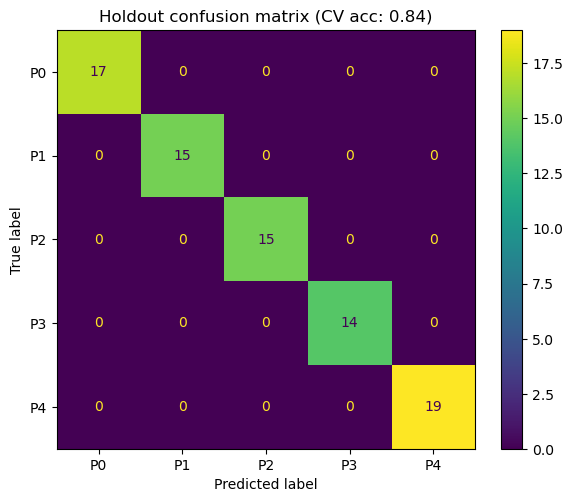

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        random_state=42,
        verbose=-1,
    )),
])

# Train final model on ALL data for submission
path_model = pipeline.fit(X, labels)

# Submission #

In [ ]:
# --- step-count + path submission ---
import re
from pathlib import Path
import pandas as pd

test_dir = Path("data/test")
submission_name = "submission_step_path.csv"

def parse_trace_id(path: Path) -> int:
    match = re.search(r"(\d+)\.pkl$", path.name)
    if match is None:
        raise ValueError(f"Could not parse Id from filename: {path.name}")
    return int(match.group(1))

rows = []

for path in sorted(test_dir.glob("*.pkl")):
    rec = Recording(str(path))
    step_pred = int(estimate_steps_windowed(rec)["steps_hat"]) #(only submits baseline)
    path_feats = extract_features(rec)
    X_path_test = pd.DataFrame([path_feats])
    path_pred = int(path_model.predict(X_path_test)[0])

    rows.append({
        "Id": parse_trace_id(path),
        "watch_loc": -1,      # default placeholder
        "path_idx": path_pred,
        "standing": -1,   # default placeholder
        "walking": -1,    # default placeholder
        "running": -1,    # default placeholder
        "cycling": -1,    # default placeholder
        "step_count": step_pred,
    })

submission_df = pd.DataFrame(rows).sort_values("Id")

# optional sanity checks
print(submission_df.head())
print(f"\nRows: {len(submission_df)}")
print(f"Step count min/max: {submission_df['step_count'].min()} / {submission_df['step_count'].max()}")

submission_df.to_csv(submission_name, index=False)
print(f"\nSaved submission to {submission_name}")

   Id  watch_loc  path_idx  standing  walking  running  cycling  step_count
0   0         -1        -1        -1       -1       -1       -1         975
1   1         -1        -1        -1       -1       -1       -1         253
2   2         -1        -1        -1       -1       -1       -1         376
3   3         -1        -1        -1       -1       -1       -1        1093
4   4         -1        -1        -1       -1       -1       -1        1012

Rows: 280
Step count min/max: 0 / 1430

Saved submission to submission_step_count_ML1.csv
